In [2]:
import psycopg, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
conn = psycopg.connect(host='its_postgresql', port=5432, dbname='techstore_dw', user='postgres', password='postgres')
print('Connessione OK')

Connessione OK


Esercizio 1 - Distribuzione delle categorie prodotto

In [4]:
df = pd.read_sql('''SELECT categoria, COUNT(*) n FROM fact_vendite fv JOIN dim_prodotto dp ON fv.prodotto_sk=dp.prodotto_sk GROUP BY categoria''', conn)
df['prob'] = df['n']/df['n'].sum()
df 

/tmp/ipykernel_377/1910655316.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql('''SELECT categoria, COUNT(*) n FROM fact_vendite fv JOIN dim_prodotto dp ON fv.prodotto_sk=dp.prodotto_sk GROUP BY categoria''', conn)


,categoria,n,prob
0,Accessori,28262,0.143572
1,Audio,22707,0.115352
2,Componenti,22345,0.113513
3,Gaming,22474,0.114169
4,Laptop,28087,0.142683
5,Smartphone,28092,0.142708
6,Smartwatch,22442,0.114006
7,Tablet,22440,0.113996


Esercizio 2 - Distribuzione della fascia di età

In [9]:
df_eta = pd.read_sql('''SELECT dc.fascia_eta, COUNT(*) AS f FROM fact_vendite fv JOIN dim_cliente dc ON dc.cliente_sk=fv.cliente_sk GROUP BY dc.fascia_eta''', conn)
df_eta['prob'] = df_eta['f']/df_eta['f'].sum()
df_eta

/tmp/ipykernel_377/1640225294.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_eta = pd.read_sql('''SELECT dc.fascia_eta, COUNT(*) AS f FROM fact_vendite fv JOIN dim_cliente dc ON dc.cliente_sk=fv.cliente_sk GROUP BY dc.fascia_eta''', conn)


,fascia_eta,f,prob
0,18-24,17805,0.090450
1,25-39,46260,0.235002
2,40-59,60486,0.307271
3,60+,72298,0.367276


Esercizio 3 - Tabella di contingenza Categoria x Fascia Età

/tmp/ipykernel_377/1059358527.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_ct = pd.read_sql('''SELECT fascia_eta, categoria, COUNT(*) n


<Axes: xlabel='categoria', ylabel='fascia_eta'>

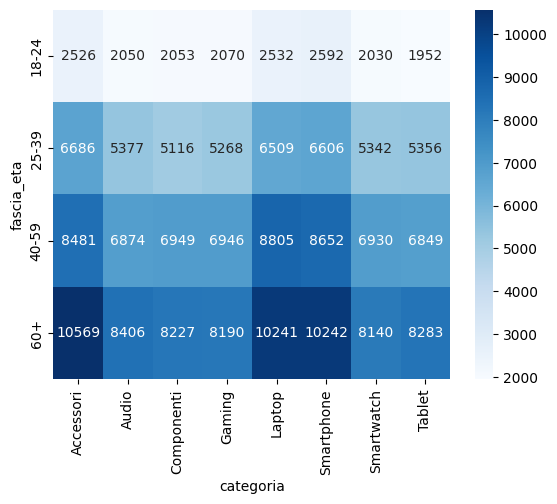

In [11]:
df_ct = pd.read_sql('''SELECT fascia_eta, categoria, COUNT(*) n 
FROM fact_vendite fv 
JOIN dim_cliente dc ON fv.cliente_sk=dc.cliente_sk 
JOIN dim_prodotto dp ON fv.prodotto_sk=dp.prodotto_sk
GROUP BY fascia_eta, categoria''', conn)
pivot=df_ct.pivot(index='fascia_eta', columns='categoria', values='n')
sns.heatmap(pivot, annot=True, fmt='d', cmap='Blues')

Esercizio 4 - Probabilità condizionata: P(Laptop|18-25)

In [12]:
#P(Laptop | 18-25)
df_ct

#completare con P(A|B)=P(A,B)/P(B)
#Esercizio 4 - Probabilità condizionata: P(Categoria | Fascia Età)

#Seleziono la riga corrispondente alla fascia di età desiderata
#In questo esempio consideriamo la fascia 18-24
riga = pivot.loc['18-24']

#Calcolo il totale delle vendite per quella fascia
totale_fascia = riga.sum()

#Probabilità condizionata: vendite per categoria / totale fascia 
prob_condizionata = riga / totale_fascia

#Mostro il risultato
prob_condizionata

p_laptop = prob_condizionata['Laptop']
print(f"P(Laptop | 18-24) = {p_laptop:.4f}")


P(Laptop | 18-24) = 0.1422


Esercizio 5 - Probabilità condizionata inversa: P(18-25 | Smartphone)

In [18]:
#P(18-25 | Smartphone)
#usare tabella df_ct 
df_ct 

#Seleziono la colonna corrispondente a Smartphone 
colonna_smartphone = pivot['Smartphone']

#Calcolo il totale delle vendite per quella colonna
totale_colonna = colonna_smartphone.sum() 

#Probabilità condizionata: vendite per colonna / totale colonna
prob_condizionata = colonna_smartphone / totale_colonna

#Mostro risultato
prob_condizionata

p_18_25 = prob_condizionata['18-24']
print(f"P(18-25 | Smartphone) = {p_18_25:.4f}")



P(18-25 | Smartphone) = 0.0923


Esercizio 6 - doppia condizione: P(Laptop | 18-25 AND fascia costo alto)

In [39]:
df = pd.read_sql (''' SELECT 
    dc.fascia_eta,
    dp.categoria,
    SUM(fv.ricavi) / sum(fv.quantita) AS costo_medio_categoria,
    COUNT(*) AS n
FROM fact_vendite fv
JOIN dim_cliente dc ON fv.cliente_sk=dc.cliente_sk 
JOIN dim_prodotto dp ON fv.prodotto_sk=dp.prodotto_sk
GROUP BY dc.fascia_eta, dp.categoria;
''', conn)

#Fasce di costo prodotto per categoria
df['fascia_costo'] = pd.cut( #suddivido la colonna con cut
    df['costo_medio_categoria'], 
    bins=[0, 300, 800, 2000], 
    labels=['basso', 'medio', 'alto'])

#Esempio: P(Laptop | fascia 18-24 AND fascia_costo 'alto')
fascia = '18-24'
fascia_alta = 'alto'
categoria = 'Laptop'

subset = df[
    (df['fascia_eta'] == fascia) & (df['fascia_costo'] == fascia_alta)
    ]

print(subset) 

totale = subset['n'].sum()
print(totale)
n_categoria = subset.loc[subset['categoria'] == categoria, 'n'].sum()


p = n_categoria / totale
p

  fascia_eta   categoria  costo_medio_categoria     n fascia_costo
1      18-24       Audio             859.446273  2050         alto
4      18-24      Laptop             901.257059  2532         alto
5      18-24  Smartphone             935.311651  2592         alto
7      18-24      Tablet            1130.992439  1952         alto
9126


/tmp/ipykernel_377/333048983.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql (''' SELECT


np.float64(0.2774490466798159)

Esercizio 7 - Calcolare la probabilità che un cliente abbia acquistato uno Smartphone, sapendo che appartiene alla fascia età 18-24, usando il Teorema di Bayes

In [42]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#1) Estraggo dati categoria per fascia d'età
df_ct 0 pd.read_sql('''
    SELECT
        dc.fascia_eta,
        dp.categoria,
        COUNT(*) AS n
    FROM fact_vendite fv
    JOIN dim_cliente dc ON fv.cliente_sk = dc.cliente_sk
    JOIN dim_prodotto dp ON fv.prodotto_sk = dp.prodotto_sk
    GROUP BY dc.fascia_eta, dp.categoria;
    ''', conn)

pivot = df_ct.pivot(index='fascia_eta', colums='categoria', values='n').fillna(0)

#P(Smartphone | 18-24)
#P(18-24 | Smartphone) * P(Smartphone) / P(18-24)  
#P(B) = Smartphone
#P(A) = 18-24

#=================================
#STEP 1 - PRIOR: P(Smartphone)
cat_smartphone = 'Smartphone'
n_smartphone = df_ct.loc[df_ct['categoria'] == cat_smartphone, 'n'].sum()
p_b = n_smartphone / df_ct['n'].sum()
print(f"P(Smartphone) = {p_b:.4f}")


#=================================
#STEP 2 - LIKELIHOOD: P(18-24 | Smartphone)
col = pivot['Smartphone']
p_likelihood = col.loc['18-24'] / col.sum()

p_18_24 = prob_condizionata['18-24']
print(f"Likelihood P(18-24 | Smartphone) =", p_likelihood")


#=================================
#STEP 3 - EVIDENCE: P(18-24)
eta_18_24 = '18-24'
n_18_24 = df_ct.loc[df_ct['fascia_eta'] == eta_18_24, 'n'].sum()
p_b = n_18_24 / df_ct['n'].sum()



#=================================
#STEP 4 - POSTERIOR: Bayes
p_posterior = (p_likelihood * p_prior) / p_evidence
print("\nPosterior P(Smartphone | 18-24)=", p_posterior)




P(Smartphone) = 0.1427
